In [16]:
import pandas as pd
import numpy as np
import json
import os
import torch

In [17]:
def count_parameters(path: str):
    model: dict = torch.load(path, map_location='cpu', weights_only=True)
    num_params = 0
    num_params_non_zero = 0
    for k, v in model.items():
        num_params += v.numel()
        num_params_non_zero += (v != 0).sum().item()
    return int(num_params_non_zero)
def count_parameters_all(path: str):
    return count_parameters(os.path.join(path, "model.pth")) + count_parameters(os.path.join(path, "relation_classifier.pth"))

In [18]:
def rename(name):
    name_dict = {
        "LargeOctreeNCA2D": "SG-NCA",
        "SurgicalSegFormer": "SegFormer",
        "SurgicalUNet": "UNet",
        "SurgicalSwinUNet": "SwinUNet",
        "TinySurgicalUNet": "TinyUNet",
    }
    return name_dict.get(name, name)

In [19]:
models = [
    #"/local/scratch/clmn1/videoNCA/CholecDataset/different-thunder-64", # (better prior; not fine-grained)
    #"/local/scratch/clmn1/videoNCA/CholecDataset/earthy-oath-63", # (better prior; not fine-grained)
    #"/local/scratch/clmn1/videoNCA/CholecDataset/kind-darling-74",
    "/local/scratch/clmn1/videoNCA/CholecDataset/dazzling-carnation-75",

    "/local/scratch/clmn1/videoNCA/CholecDataset/fragrant-frost-54",
    "/local/scratch/clmn1/videoNCA/CholecDataset/still-plant-78",
    "/local/scratch/clmn1/videoNCA/CholecDataset/driven-oath-49",
    "/local/scratch/clmn1/videoNCA/CholecDataset/effortless-water-55",
]

df = []
for model in models:
    sg_results = json.load(open(os.path.join(model, "scene_graph_evaluation_val.json"), "r"))
    config = json.load(open(os.path.join(model, "config.json"), "r"))
    K = sg_results["K"]

    df.append({
        "name": rename(config["model"]),
        "model": config["model"],
        "method": config["relation_config"]["method"],
        f"Recall@{K}": sg_results["Recall@K"],
        f"mRecall@{K}": sg_results["mRecall@K"],
        f"mAP@{K}": sg_results["mAP@K"],
        "num_params_rel": count_parameters(os.path.join(model, "relation_classifier.pth")),
        "num_params_seg": count_parameters(os.path.join(model, "model.pth")),
        "num_params_all": count_parameters_all(model),
    })

df = pd.DataFrame(df)
df

,name,model,method,Recall@4,mRecall@4,mAP@4,num_params_rel,num_params_seg,num_params_all
0,SG-NCA,LargeOctreeNCA2D,direct_prediction,0.717905,0.561689,0.277136,137897,27465,165362
1,UNet,SurgicalUNet,motif,0.682554,0.457199,0.250914,4490761,68331670,72822431
2,TinyUNet,TinySurgicalUNet,motif,0.654332,0.501610,0.262185,274825,268030,542855
3,SegFormer,SurgicalSegFormer,motif,0.661856,0.417506,0.244576,6325769,3717484,10043253
4,SwinUNet,SurgicalSwinUNet,motif,0.669491,0.542002,0.317842,4621833,27941028,32562861


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="deep"
)
x_col = "num_params_all"

metrics = {
    f"Recall@{K}": {"label": "Recall@K", "marker": "o"},
    f"mRecall@{K}": {"label": "mRecall@K", "marker": "s"},
    f"mAP@{K}": {"label": "mAP@K", "marker": "D"},
}


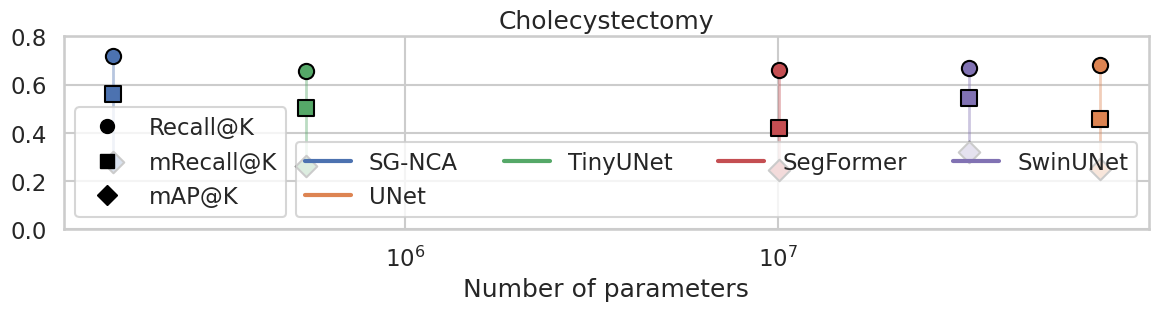

In [21]:
methods = df["name"].unique()
palette = dict(zip(methods, sns.color_palette(n_colors=len(methods))))

plt.figure(figsize=(14, 2.5))

for _, row in df.iterrows():
    x = row[x_col]
    color = palette[row["name"]]

    plt.vlines(
        x=x,
        ymin=min(row[m] for m in metrics),
        ymax=max(row[m] for m in metrics),
        color=color,
        alpha=0.4,
        linewidth=2
    )

    for m, cfg in metrics.items():
        plt.scatter(
            x,
            row[m],
            marker=cfg["marker"],
            s=120,
            color=color,
            edgecolor="black",
            zorder=3
        )
from matplotlib.lines import Line2D
metric_handles = [
    Line2D(
        [0], [0],
        marker=cfg["marker"],
        color="black",
        linestyle="None",
        markersize=10,
        label=cfg["label"]
    )
    for cfg in metrics.values()
]
model_handles = [
    Line2D(
        [0], [0],
        color=palette[model],
        lw=3,
        label=model
    )
    for model in methods
]
ax = plt.gca()

if True:
    legend_metrics = ax.legend(
        handles=metric_handles,
        #title="Metric",
        loc="lower left",
        frameon=True
    )

    ax.add_artist(legend_metrics)  # keep first legend

    ax.legend(
        handles=model_handles,
        #title="Model",
        loc="lower right",
        frameon=True,
        ncol=4
    )

plt.title("Cholecystectomy")
plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylim(0, 0.8)
plt.savefig("plots/cholec_relation.pdf", bbox_inches="tight")